In [1]:
import math

from typing import List
import random

In [5]:
class Value:
    """ 
    Stores a single scalar value and the partial derivative of the root node with respect to the value (treated as a variable) 
    
    When an expression is formed, a tree is created FROM THE LEAFES TO THE ROOT.
    It is important to understand this in order to understand how the backpropagation is made
    """

    def __init__(self, data : float, children=(), op='', label=""):
        # Public attributes

        # Scalar value to be stored
        self.data : float = data
        
        # Partial derivative of the root node with respect to {label}
        self.grad : int = 0
        
        # Label of the variable ("variable name")
        self.label : str = label
        
        # Private (internal) variables used for autograd graph construction
        
        # Function for calculating the partial derivative of a node with respect to its inputs.
        # In a sense, input nodes generate an output node and THIS OUTPUT NODE is the one that calculates and assigns the partial derivates
        # of its inputs.
        # NOTE: When a node is a leaf node, this function will be lambda: None
        self.__backward : callable = lambda: None  
        
        # Set of childrens of this node
        self.__children : set = set(children) 
        
        # Operation that generated this node
        self.__op : chr = op

    # Method for checking if a value {other} is an instance of 'Value'. If it is, just return it.
    # If its not, it checks if its an instance of a numeric type and wraps it with a 'Value' type, then return it.
    # Else, throws an exception...
    def __wrapValue(self, other):

        # We check if other is a 'Value' class instance
        if not isinstance(other, Value):

            # Check if its a numeric type
            if isinstance(other, (int, float)) and not isinstance(other, bool):
                # Wrap into a value class
                return Value(other, label=str(other))
            
            # other can only by 'Value' or numeric type
            else:
                raise Exception("Type error: trying to operate a non numeric value!")
        
        else: 
            return other


    # Addition operation overloading
    def __add__(self, other) -> 'Value':
        
        # Check if the value we are trying to sum is valid, in that case assign it
        other = self.__wrapValue(other)
        
        out =  Value(self.data + other.data, children=(self, other), op = '+', label=f"{self.label}+{other.label}")

        # We assign the backwards function to the generated node. 
        # We are telling it should calculate and assign its partial derivatives
        # 
        # By chain rule, the partial derivative of this node and its brother will be += 1*d{out}/d{label}
        def __backward():
            self.grad  += 1*out.grad
            other.grad += 1*out.grad
        
        # With this line, we tell the out node how it should calculate its partial derivatives with respect each and one of its variables 
        out.__backward = __backward 

        return out

    # Multiplication operation overloading
    def __mul__(self, other) -> 'Value':

        other = self.__wrapValue(other)
        
        out =  Value(self.data*other.data, children=(self, other), op = '*', label=f"{self.label}*{other.label}")

        def __backward():
            self.grad  += other.data*out.grad
            other.grad += self.data*out.grad
        out.__backward = __backward 

        return out
    
    # Exponentiation operation overloading
    def __pow__(self, other) -> 'Value':
        
        other = self.__wrapValue(other)
        
        out =  Value(self.data**(other.data), children=(self, other), op = '^', label=f"{self.label}^{other.label}")

        def __backward():
            self.grad  += other.data*(self.data**(other.data - 1))*out.grad
            other.grad += (self.data**(other.data))*math.log(self.data)*out.grad
        out.__backward = __backward 

        return out        

    # Sigmoid operation
    def sigmoid(self) -> 'Value':

        s = 1/(1+math.exp(-self.data))
        out =  Value(s, children=(self), op = 'sig', label=f"sig({self.label})")

        def __backward():
            self.grad  += (s*(1-s))*out.grad
        out.__backward = __backward 

        return out       

    # ReLU operation
    def relu(self) -> 'Value':

        r = self.data if self.data > 0 else 0
        out =  Value(r, children=(self,), op = 'ReLU', label=f"ReLU({self.label})")

        def __backward():
            self.grad  += 1*out.grad if self.data > 0 else 0
        out.__backward = __backward 

        return out

    # Division (/) operation overloading
    def __truediv__(self, other) -> 'Value':
        return self*(other**(-1))

    # Negation (-) operation overloading
    def __neg__(self) -> 'Value':
        return self * (-1)

    # Substraction operation overloading
    def __sub__(self, other) -> 'Value':
        return self + (-other)
    
    # "Right addition" (eg. other + self)
    def __radd__(self, other) -> 'Value':
        return self + other

    # "Right substraction"
    def __rsub__(self, other) -> 'Value':
        return other + (-self)
    
    # "Right multiplication"
    def __rmul__(self, other) -> 'Value':
        return self*other
    
    # "Right division"
    def __rtruediv__(self, other) -> 'Value':
        return (self**(-1))*other

    # "Right exponentiation"
    def __rpow__(self, other) -> 'Value':
        other = self._wrapValue(other)
        return other**self

    # "tostring" method
    def __repr__(self) -> str:
        return f"Value(data={self.data}, grad={self.grad})"
    
    # Method for calculating the partial derivatives of the root node wrt ALL of its inputs 
    def backward(self):

        # First, we do a topological sort of the tree
        topo = []
        visited = set()

        # Function for doing the topological sort...
        def build_topo(v : Value) -> None:
            if v not in visited:
                visited.add(v)
                for child in v.__children:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        
        # We set the partial derivate of the root node wrt to the root node to 1
        self.grad = 1
        
        # Go one variable at a time and apply the chain rule to get its gradient
        for i in range(len(topo) - 1, 0, -1):
            v = topo[i]
            v.__backward()

    # Method for getting the children of this node (useful for drawing the entire tree...)
    def getChildren(self) -> set:
        return self.__children
    
    # Method for getting a string representing the operation used for creating this node (useful for drawing the entire tree...)
    def getOperation(self) -> str:
        return self.__op

In [14]:
'''
Class that models a layer of a flat Neural Network.
Each layers holds information of (attributes):

* current_activation                  : features vector outputted by the layer (also known as activation vector)

* weights                             : weights of the conecction between the current layer (self) and the previous layer (except for the input layer,
                                        where the weights matrix is the identity)
      
* prev_weights                        : weights of the previous iteration (for calculating the momentum term)
                                        
* bias                                : bias vector (if the layer is the input layer, then the bias vector is the zero vector)
              
* act_function                        : activation function. Is an object of the class Function. This object holds a callable for the function and its derivative
              
* input_layer                         : boolean for evaluating if the layer is an input layer
  (SHOULD NOT BE ACCESED BY THE USER)
'''

class Layer:

    def __init__(self, in_features : int, out_features : int, input_layer : bool):
        '''
        @params:
        * in_features  : Dimension of the features vector received by the layer

        * out_features : Dimension of the features vector outputted by the layer

        * act_function : Activation function

        * input_layer  : If True, then the layer is an input layer
        '''

        k = 1/in_features
        
        if input_layer : 
            '''
            If the layer is the input layer, then we set the weights matrix to be the identity and the 
            bias vector to be the zero vector
            '''

            self.weights = [[Value(1, label=f"w_{i + 1}{j + 1}") if i == j else Value(0, label=f"w_{i+1}{j+1}") for j in range(in_features)] for i in range(in_features)] 
            self.bias = [0]*in_features
        else : 
            '''
            If the layer is a hidden/output layer, then we set the weights matrix to be out_feautes x in_features dimensional,
            and the bias vector to be out_features-dimensional
            '''

            self.weights = [[Value(random.uniform(-math.sqrt(k),math.sqrt(k)), label=f"w_{i + 1}{j + 1}") for j in range(in_features)] for i in range(out_features)]

            self.bias = [Value(random.uniform(-math.sqrt(k),math.sqrt(k)), label=f"b_{i + 1}") for i in range(out_features)]


        self.current_activation = None

        self.input_layer = input_layer
    
    #------------GETTERS------------#
    def getWeights(self):
        '''returns the weights matrix of the layer'''
        return self.weights

    def getBias(self):
        '''returns the bias vector of the layer'''
        return self.bias

    def getActivation(self):
        '''returns the activation vector of the layer'''
        return self.current_activation 
    #-------------------------------#

    #------------SETTERS------------#
    def setWeights(self, new_weights : List[List[Value]]):
        '''sets the weights matrix of the layer'''
        self.prev_weights = self.weights
        self.weights = new_weights
    
    def setBias(self, new_bias : List[Value]):
        '''sets the bias vector of the layer'''
        self.bias = new_bias
    #-------------------------------#
        
    


In [15]:
'''
Class that models a flat Neural Network layer that uses a Rectified Linear Unit (ReLU) as activation function
'''

class ReLU(Layer):
    def __init__(self, in_features : int, out_features : int, input_layer : bool):
        super().__init__(in_features, out_features, input_layer)
        self.current_activation = []
    
    def __call__(self, prev_act : List[Value]):
        '''
        obtains the activation of the layer

        @params:
        * prev_act : Feature vector feeded to the layer (previous activation vector)
        '''
        
        '''
        the expression being evaluated is:
        a_c = ReLU(W*a_c-1 + b)
        '''
        self.current_activation = [sum((w_i * a_i for w_i, a_i in zip(self.weights[i], prev_act)), self.bias[i]) for i in range(len(self.weights))]
        self.current_activation = [act.relu() for act in self.current_activation]
        
        return self.current_activation
    
'''
Class that models a flat Neural Network layer that uses a Sigmoid as activation function
'''

class Sigmoid(Layer):
    def __init__(self, in_features : int, out_features : int, input_layer : bool):
        super().__init__(in_features, out_features, input_layer)
        self.current_activation = []
    
    def __call__(self, prev_act : List[Value]):
        '''
        obtains the activation of the layer

        @params:
        * prev_act : Feature vector feeded to the layer (previous activation vector)
        '''
        
        '''
        the expression being evaluated is:
        a_c = ReLU(W*a_c-1 + b)
        '''
        self.current_activation = [sum((w_i * a_i for w_i, a_i in zip(self.weights[i], prev_act)), self.bias[i]) for i in range(len(self.weights))]
        self.current_activation = [act.sigmoid() for act in self.current_activation]
        
        return self.current_activation

In [58]:
'''
Class that models a Tensor. That meaning, a multidimensional array of Values
'''

# TODO: FIXXXX
class Tensor:
    def __fillListWithValues(self, currentList : List, resultList : List):
        
        if(isinstance(currentList[0], float) or isinstance(currentList[0], int)) :
            newList = list(map(lambda x : Value(x), currentList))
            return newList
        
        else:
            newList = [list()]*len(currentList)
            for i in range(len(currentList)):
                resultList.append(self.__fillListWithValues(currentList[i], newList[i]))

    def __init__(self, *args):
        
        self.__data : List = []

        # First we check if we have more than 1 argument
        if len(args) > 1: raise Exception("Tensor class only admits 0 or 1 argument(s)!")

        else:
            # If we have no arguments, we create an empty tensor
            if len(args) == 0:
                pass
            
            # If we have one argument, we are expecting it to be an n-dimensional tensor
            else:
                self.__fillListWithValues(args[0], self.__data)
    
    def getData(self):
        return self.__data

In [17]:
'''
Class that models a Sequential Container (list of layers of a Neural Network in which forward pass is implemented)
Each MLP holds information of (attributes):

* layers : list of layers that make up the sequential container

'''

class Sequential:

    def __init__(self, *layers):
        '''
        @params:
        * layers : list of layers that make up the sequential container
        '''
        self.__layers : List[List[Value]] = layers
        
    def __call__(self, input_vect : List[Value]):
        '''
        forwards an input vector through the layers, returning an output vector

        @params:
        * input_vector : vector to be forwarded

        @returns:
        * activation : activation of the last layer for the forwarded vector
        '''
        activation = (self.__layers[0])(input_vect)
        for i in range(1, len(self.__layers)):
            activation = (self.__layers[i])(activation)
        return activation

# Use case: Creation of a Neural Network

In [61]:
input = [3, 4, 5,6,7,8]

t = Tensor(input)
print(t.getData())

[]


In [19]:
class MLP:
    def __init__(self):
        self.layers = Sequential(
            ReLU(2,2),
            Sigmoid(2,1)
        )

        self.lr = 0.1 # Learning rate
    
    def forward(self, input : List[float]):
        
        # We convert the input to a tensor
        input = Tensor(input)

        # Now we do the forward pass
        return self.layers(input)


# VISUALIZATION FUNCTION

In [3]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v.getChildren():
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n.getOperation():
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n.getOperation(), label = n.getOperation())
      # and connect this node to it
      dot.edge(uid + n.getOperation(), uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2.getOperation())

  return dot

# TESTS

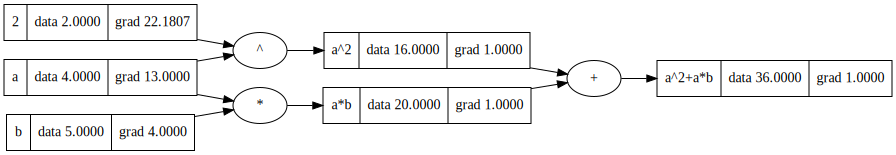

In [6]:
x = Value(4, label="a")
y = Value(5, label="b")

a = x ** 2
b = x*y

f = a + b

f.backward()
draw_dot(f)

In [ ]:
l = ReLU(3,1,False)

input = [Value(1, label="x1"), Value(1, label="x2"), Value(1, label="x3")]

res = l(input)
res

TypeError: 'Value' object is not iterable

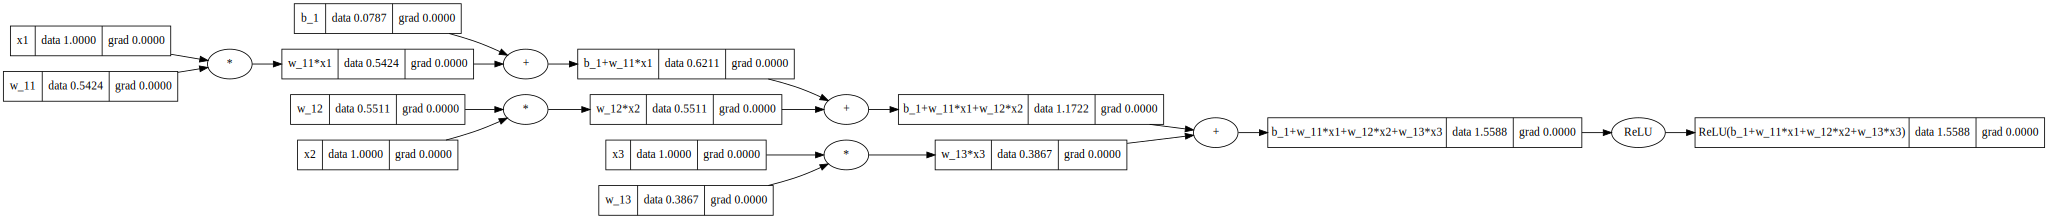

In [ ]:
draw_dot(res)